In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
train = pd.read_csv('../train_cleaned.csv')
test = pd.read_csv('../test_cleaned.csv')
feature_cols = [
    "Applied_Voltage_kV", "Load_Current_A", "Ambient_Temperature_C", "Test_Duration_min",
    "Sensor_S1", "Sensor_S2", "Sensor_S3",
    "S1_missing", "S2_missing", "S3_missing", "S4_missing",
    "is_duplicate_input"
]

In [11]:
X = train[feature_cols]
y_class = train["Validity_Label_enc"]
y_reg = train["Reference_Parameter"]

X_train, X_val, y_class_train, y_class_val, y_reg_train, y_reg_val = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [13]:
X_val

,Applied_Voltage_kV,Load_Current_A,Ambient_Temperature_C,Test_Duration_min,Sensor_S1,Sensor_S2,Sensor_S3,S1_missing,S2_missing,S3_missing,S4_missing,is_duplicate_input
369,25.6003,45.6984,36.3889,34.2858,15.3215,14.1184,19.8526,0,0,0,0,0
432,14.2264,65.2297,43.6970,14.8851,10.7876,12.0693,13.4388,0,0,0,0,0
837,19.1530,39.1288,27.4245,59.0660,14.4508,18.5147,15.8739,0,0,0,0,0
79,31.8012,33.9683,33.2320,36.4063,17.3683,15.0914,22.6319,0,0,0,0,0
184,31.1752,99.3175,25.9078,5.0950,20.6205,20.1688,25.4065,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
793,11.3923,89.2344,39.1595,59.9745,10.9529,13.1016,13.2032,0,0,0,0,0
157,19.1900,70.3763,45.3644,54.5215,13.7609,14.6353,17.4645,0,0,0,0,0
783,10.9793,47.4117,37.1060,33.0558,8.1981,9.3620,10.0748,0,0,0,0,0
803,21.3349,46.1014,34.2588,5.2606,12.5252,12.1878,16.1059,0,0,0,0,0


In [14]:
print(y_class_train.value_counts(normalize=True))
print(y_class_val.value_counts(normalize=True))
# Both should show ~0.866 / 0.134

Validity_Label_enc
0    0.86625
1    0.13375
Name: proportion, dtype: float64
Validity_Label_enc
0    0.865
1    0.135
Name: proportion, dtype: float64


In [18]:
try:
    import lightgbm
    print("lightgbm available:", lightgbm.__version__)
except ImportError:
    print("lightgbm NOT available")

try:
    import xgboost
    print("xgboost available:", xgboost.__version__)
except ImportError:
    print("xgboost NOT available")

lightgbm available: 4.7.0
xgboost NOT available


In [20]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

f1_scores = []
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_class)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y_class.iloc[train_idx], y_class.iloc[val_idx]

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_tr, y_tr)

    preds = clf.predict(X_vl)
    probs = clf.predict_proba(X_vl)[:, 1]

    f1 = f1_score(y_vl, preds)
    auc = roc_auc_score(y_vl, probs)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"Fold {fold}: F1={f1:.4f}, AUC={auc:.4f}")

print(f"\nMean F1: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"Mean AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")

Fold 0: F1=0.7317, AUC=0.9956
Fold 1: F1=0.6829, AUC=0.9988
Fold 2: F1=0.7143, AUC=0.9979
Fold 3: F1=0.5405, AUC=0.9981
Fold 4: F1=0.8980, AUC=0.9981

Mean F1: 0.7135 (+/- 0.1142)
Mean AUC: 0.9977 (+/- 0.0011)


In [21]:
from sklearn.metrics import precision_recall_curve

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_class)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y_class.iloc[train_idx], y_class.iloc[val_idx]

    clf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    probs = clf.predict_proba(X_vl)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_vl, probs)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = f1s.argmax()
    print(f"Fold {fold}: best threshold={thresholds[best_idx]:.3f}, best F1={f1s[best_idx]:.4f} (default 0.5 F1 was {f1_scores[fold]:.4f})")

Fold 0: best threshold=0.183, best F1=0.9231 (default 0.5 F1 was 0.7317)
Fold 1: best threshold=0.177, best F1=0.9630 (default 0.5 F1 was 0.6829)
Fold 2: best threshold=0.137, best F1=0.9474 (default 0.5 F1 was 0.7143)
Fold 3: best threshold=0.167, best F1=0.9643 (default 0.5 F1 was 0.5405)
Fold 4: best threshold=0.203, best F1=0.9643 (default 0.5 F1 was 0.8980)


In [22]:
clf_full = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
clf_full.fit(X, y_class)

importances = pd.Series(clf_full.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

Sensor_S2                0.211982
Sensor_S1                0.186079
Sensor_S3                0.150482
is_duplicate_input       0.106073
Load_Current_A           0.074398
Applied_Voltage_kV       0.071325
Test_Duration_min        0.067336
Ambient_Temperature_C    0.061324
S3_missing               0.032375
S1_missing               0.028574
S2_missing               0.008383
S4_missing               0.001670
dtype: float64


In [23]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    clf_full, X, y_class,
    n_repeats=30,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

perm_importances = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)
print(perm_importances)

Sensor_S2                0.347926
Sensor_S1                0.215707
is_duplicate_input       0.167126
Sensor_S3                0.149362
S3_missing               0.048789
S1_missing               0.040589
Load_Current_A           0.029762
Test_Duration_min        0.029134
Ambient_Temperature_C    0.019696
Applied_Voltage_kV       0.012617
S2_missing               0.007519
S4_missing               0.000000
dtype: float64


In [24]:
best_thresholds = [0.183, 0.177, 0.137, 0.167, 0.203]  # replace with your actual fold values
final_threshold = np.mean(best_thresholds)
print(final_threshold)

0.1734


In [25]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [27]:
rmse_scores = []
mae_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y_reg.iloc[train_idx], y_reg.iloc[val_idx]

    reg = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    reg.fit(X_tr, y_tr)

    preds = reg.predict(X_vl)

    rmse = np.sqrt(mean_squared_error(y_vl, preds))
    mae = mean_absolute_error(y_vl, preds)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

    print(f"Fold {fold}: RMSE={rmse:.4f}, MAE={mae:.4f}")

print(f"\nMean RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
print(f"Mean MAE: {np.mean(mae_scores):.4f} (+/- {np.std(mae_scores):.4f})")

Fold 0: RMSE=1.2253, MAE=0.7347
Fold 1: RMSE=2.6956, MAE=0.9574
Fold 2: RMSE=1.5776, MAE=0.8350
Fold 3: RMSE=3.0513, MAE=1.1327
Fold 4: RMSE=2.5334, MAE=1.1343

Mean RMSE: 2.2166 (+/- 0.6953)
Mean MAE: 0.9588 (+/- 0.1591)


In [28]:
print("Reference_Parameter range:", y_reg.min(), "-", y_reg.max())
print("Reference_Parameter std:", y_reg.std())

Reference_Parameter range: 11.9183 - 61.5848
Reference_Parameter std: 10.694772214993051


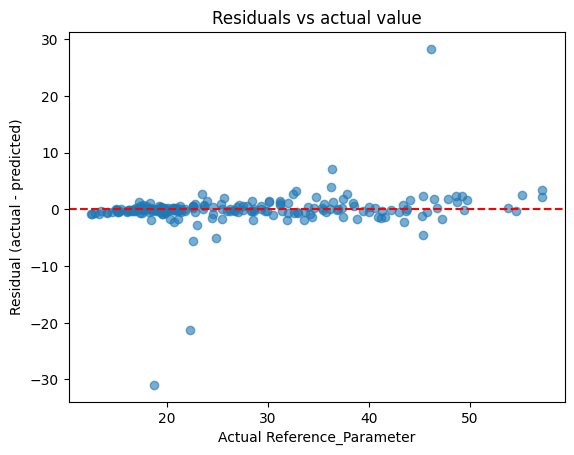

In [29]:
reg_full = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
reg_full.fit(X_train, y_reg_train)
val_preds = reg_full.predict(X_val)

residuals = y_reg_val.values - val_preds

import matplotlib.pyplot as plt
plt.scatter(y_reg_val, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Reference_Parameter")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs actual value")
plt.show()

In [30]:
perm_result_reg = permutation_importance(
    reg_full, X_val, y_reg_val,
    n_repeats=30,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_importances_reg = pd.Series(perm_result_reg.importances_mean, index=feature_cols).sort_values(ascending=False)
print(perm_importances_reg)

Load_Current_A           8.883925
Ambient_Temperature_C    1.037196
Sensor_S2                1.024816
Sensor_S3                0.290246
Sensor_S1                0.173033
Applied_Voltage_kV       0.074107
Test_Duration_min        0.000331
S4_missing               0.000050
S2_missing               0.000001
S3_missing              -0.000003
S1_missing              -0.000011
is_duplicate_input      -0.006014
dtype: float64


In [31]:
val_df = X_val.copy()
val_df["actual"] = y_reg_val.values
val_df["predicted"] = val_preds
val_df["residual"] = residuals
val_df["Validity_Label"] = train.loc[X_val.index, "Validity_Label"].values

big_errors = val_df[val_df["residual"].abs() > 10].sort_values("residual")
print(big_errors[["actual", "predicted", "residual", "Validity_Label", "is_duplicate_input"]])

      actual  predicted   residual Validity_Label  is_duplicate_input
789  18.6752  49.613017 -30.937817        Invalid                   1
387  22.2325  43.589132 -21.356632        Invalid                   1
127  46.1158  17.814124  28.301676        Invalid                   1


In [32]:
valid_mask_train = train.loc[X_train.index, "Validity_Label"] == "Valid"
X_train_validonly = X_train[valid_mask_train.values]
y_reg_train_validonly = y_reg_train[valid_mask_train.values]

print(f"Training on {len(X_train_validonly)} rows instead of {len(X_train)}")

reg_validonly = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
reg_validonly.fit(X_train_validonly, y_reg_train_validonly)

val_preds_validonly = reg_validonly.predict(X_val)

rmse_validonly = np.sqrt(mean_squared_error(y_reg_val, val_preds_validonly))
mae_validonly = mean_absolute_error(y_reg_val, val_preds_validonly)

print(f"Valid-only training: RMSE={rmse_validonly:.4f}, MAE={mae_validonly:.4f}")
print(f"All-rows training (from before): RMSE={np.sqrt(mean_squared_error(y_reg_val, val_preds)):.4f}, MAE={mean_absolute_error(y_reg_val, val_preds):.4f}")

Training on 693 rows instead of 800
Valid-only training: RMSE=3.5473, MAE=1.2433
All-rows training (from before): RMSE=3.5797, MAE=1.2289


In [33]:
final_clf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_clf.fit(X, y_class)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
final_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
final_reg.fit(X, y_reg)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
X_test_final = test[feature_cols]

print(X_test_final.shape)
# Expect: (350, 12)

(350, 12)


In [36]:
test_reg_preds = final_reg.predict(X_test_final)
test_probs = final_clf.predict_proba(X_test_final)[:, 1]

final_threshold = 0.1734  # from Step 2i

test_class_preds = (test_probs >= final_threshold).astype(int)

test_validity_labels = pd.Series(test_class_preds).map({0: "Valid", 1: "Invalid"})

sample_sub = pd.read_excel("CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx", sheet_name="Sample_Submission")
print(sample_sub.columns.tolist())
print(sample_sub.head())

['Test_ID', 'Predicted_Reference_Parameter', 'Validity_Label']
    Test_ID  Predicted_Reference_Parameter  Validity_Label
0  TST-0278                            NaN             NaN
1  TST-0006                            NaN             NaN
2  TST-0047                            NaN             NaN
3  TST-0311                            NaN             NaN
4  TST-0264                            NaN             NaN


In [37]:
submission = pd.DataFrame({
    "Test_ID": test["Test_ID"],
    "Predicted_Reference_Parameter": test_reg_preds,
    "Validity_Label": test_validity_labels
})

print(submission.head(10))
print(submission.shape)
# Expect: (350, 3)

    Test_ID  Predicted_Reference_Parameter Validity_Label
0  TST-0278                      32.397544        Invalid
1  TST-0006                      19.157111          Valid
2  TST-0047                      53.208862          Valid
3  TST-0311                      25.528105          Valid
4  TST-0264                      18.511390        Invalid
5  TST-0169                      19.190112          Valid
6  TST-0269                      18.313962          Valid
7  TST-0178                      15.939429        Invalid
8  TST-0206                      31.570731          Valid
9  TST-0038                      17.977516          Valid
(350, 3)


In [38]:
print(submission["Validity_Label"].value_counts(normalize=True))

Validity_Label
Valid      0.871429
Invalid    0.128571
Name: proportion, dtype: float64


In [39]:
submission.to_csv("submission_Random Forest.csv", index=False)